# FINA4713: Problem Set 2 — Empirical Notebook
## Credit Card Churn Prediction

**Due:** Tuesday, April 7, 2026

This notebook covers **Problems 2–4** (the empirical part). Answers to Problem 1 (analytical) should be written by hand and submitted separately.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score
)
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

---
## Problem 2 — Data Exploration *(25 points)*

In [2]:
# Provided: load data and drop columns not used as features
df = pd.read_csv('BankChurners.csv')

# Drop the customer ID and the two Naive Bayes prediction columns
# (the original dataset creator left these pre-computed scores in the file)
nb_cols = [c for c in df.columns if 'Naive_Bayes' in c]
df = df.drop(columns=['CLIENTNUM'] + nb_cols)

In [3]:
# (a) YOUR CODE: inspect the dataset
# Print the shape of the DataFrame, display the first few rows,
# show the data type of each column, and confirm there are no null values.

# YOUR CODE HERE

# Hint:
print(df.shape)
print(df.head())
print(df.dtypes)
print("number of null values: ", df.isnull().sum())


(10127, 20)
      Attrition_Flag  Customer_Age Gender  Dependent_count Education_Level  \
0  Existing Customer            45      M                3     High School   
1  Existing Customer            49      F                5        Graduate   
2  Existing Customer            51      M                3        Graduate   
3  Existing Customer            40      F                4     High School   
4  Existing Customer            40      M                3      Uneducated   

  Marital_Status Income_Category Card_Category  Months_on_book  \
0        Married     $60K - $80K          Blue              39   
1         Single  Less than $40K          Blue              44   
2        Married    $80K - $120K          Blue              36   
3        Unknown  Less than $40K          Blue              34   
4        Married     $60K - $80K          Blue              21   

   Total_Relationship_Count  Months_Inactive_12_mon  Contacts_Count_12_mon  \
0                         5                 

In [4]:
# (b) YOUR CODE: count "Unknown" entries in each categorical column
# Report how many "Unknown" values appear in each object-type column.

# YOUR CODE HERE

# Hint:
for col in df.columns:
    if df[col].dtype == 'object':
        count = (df[col] == 'Unknown').sum()
        if count: print(f'{col}: {count}')

In [5]:
# (c) YOUR CODE: compute class balance and create binary target
# Create 'Churned' column (1 = Attrited Customer, 0 = Existing Customer).
# Print the count and percentage of each class, and the overall churn rate.

df['Churned'] = (df['Attrition_Flag'] == 'Attrited Customer').astype(int)

# YOUR CODE HERE

# Hint:
print("Counts: ",df['Churned'].value_counts())
print("percentages of each class: ",df['Churned'].value_counts(normalize=True))
print("Overall churn rate: ", df['Churned'].mean() )  # overall churn rate

Counts:  Churned
0    8500
1    1627
Name: count, dtype: int64
percentages of each class:  Churned
0    0.83934
1    0.16066
Name: proportion, dtype: float64
Overall churn rate:  0.1606596227905599


**P2(c) — Written answer:** What accuracy would a naive classifier achieve by predicting "Existing Customer" for every observation? Why is accuracy a misleading metric for this dataset, and what metric(s) would be more appropriate?


It would achieve about 84% accuracy. This is misleading because it is not accurate because it is fitted well but just because there are little attrited values and we might actually be more interested in identifying attrited customers. In this case, recall would be more relevant to measure how well we identify them or f1 score that incorporates recall information in a balanced way. 

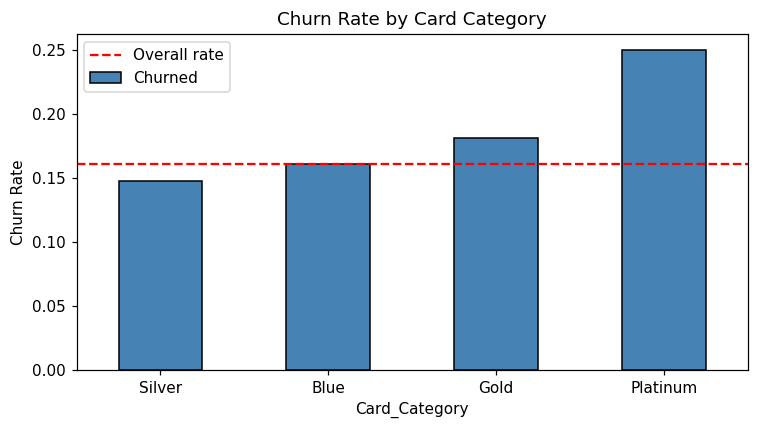

In [6]:
# (d) YOUR CODE: compute churn rate by Card_Category and plot as a bar chart
# Add a horizontal dashed reference line at the overall churn rate.

overall_churn_rate = df['Churned'].mean()
churn_by_card = df.groupby('Card_Category')['Churned'].mean().sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
# YOUR CODE HERE: plot churn_by_card as a bar chart
# YOUR CODE HERE: add a horizontal dashed reference line at overall_churn_rate

ax.set(xlabel='Card Category', ylabel='Churn Rate',
       title='Churn Rate by Card Category')

# Hint:
churn_by_card.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.axhline(y=overall_churn_rate, color='red', linestyle='--', label='Overall rate')
ax.legend()
ax.set_xticklabels(churn_by_card.index, rotation=0)
plt.tight_layout()
plt.show()

**P2(d) — Written answer:** Which card category has the highest churn rate? Offer a brief economic interpretation.

Platinum category has the highest churn rate. It may be because it is on the luxury side and hence likely to have substitutes/harsh requirements, or it may simply be because there are less people and hence rate increases as a percentage of population. 

       Existing  Churned
count   8500.00  1627.00
mean      68.67    44.93
std       22.92    14.57
min       11.00    10.00
25%       54.00    37.00
50%       71.00    43.00
75%       82.00    51.00
max      139.00    94.00


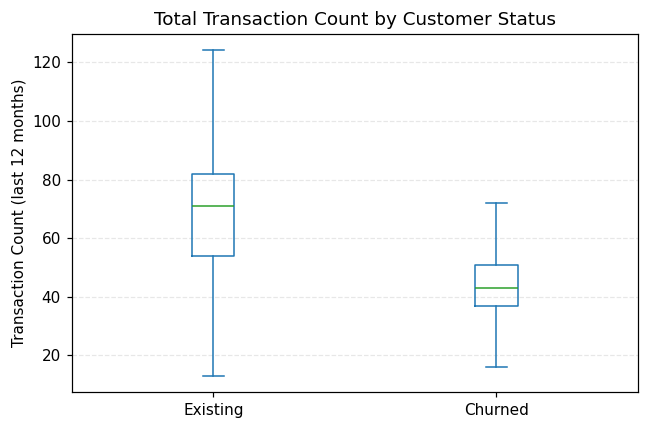

In [7]:
# (e) YOUR CODE: compare Total_Trans_Ct between churned and existing customers
# First print summary statistics, then create side-by-side box plots.

trans_by_status = pd.DataFrame({
    'Existing': df[df['Churned'] == 0]['Total_Trans_Ct'],
    'Churned':  df[df['Churned'] == 1]['Total_Trans_Ct']
})
print(trans_by_status.describe().round(2))

fig, ax = plt.subplots(figsize=(6, 4))
# YOUR CODE HERE: plot side-by-side box plots

ax.set(ylabel='Transaction Count (last 12 months)',
       title='Total Transaction Count by Customer Status')

# Hint:
trans_by_status.plot(kind='box', ax=ax, showfliers=False)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout(); plt.show()


**P2(e) — Written answer:** By approximately how much does the median transaction count differ between churned and existing customers? What does this suggest about the relationship between card usage and churn?

It differs by about 28 (71 to 43), this suggests a negative relationship between usage frequency and churn rate. Churners have a significantly lower frequency. 

---
## Problem 3 — Logistic Regression *(25 points)*

In [8]:
# Provided: define feature lists and stratified train-test split
cat_features = ['Gender', 'Education_Level', 'Marital_Status',
                'Income_Category', 'Card_Category']
num_features = [c for c in df.columns
                if c not in cat_features + ['Attrition_Flag', 'Churned']]

X = df.drop(columns=['Attrition_Flag', 'Churned'])
y = df['Churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print('Train churn rate:', round(y_train.mean(), 4))
print('Test  churn rate:', round(y_test.mean(), 4))

# Provided: one-hot encoding for logistic regression + standardization
X_train_enc = pd.get_dummies(X_train, columns=cat_features, drop_first=True)
X_test_enc  = pd.get_dummies(X_test,  columns=cat_features, drop_first=True)
X_test_enc  = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

scaler = StandardScaler()
X_train_enc[num_features] = scaler.fit_transform(X_train_enc[num_features])
X_test_enc[num_features]  = scaler.transform(X_test_enc[num_features])

Train churn rate: 0.1607
Test  churn rate: 0.1604


In [9]:
# (a) YOUR CODE: fit logistic regression and evaluate at the default threshold t=0.50
lr = LogisticRegression(max_iter=1000)   # fill in an appropriate value for max_iter

# fit the model
lr.fit(X_train_enc, y_train)

# predicted probabilities for class 1 = Churned
y_prob_lr = lr.predict_proba(X_test_enc)[:, 1]

# predicted labels at t = 0.50
y_pred_05 = lr.predict(X_test_enc)

# print classification report
print(classification_report(y_test, y_pred_05, target_names=['Existing', 'Churned']))

# Hint:
#   lr.fit(X_train_enc, y_train)
#   lr.predict_proba(X_test_enc)[:, 1]    — predicted probabilities for class 1
#   lr.predict(X_test_enc)                — predicted labels at t=0.5
#   classification_report(y_test, y_pred_05, target_names=['Existing', 'Churned'])

              precision    recall  f1-score   support

    Existing       0.92      0.97      0.94      1701
     Churned       0.77      0.54      0.64       325

    accuracy                           0.90      2026
   macro avg       0.84      0.76      0.79      2026
weighted avg       0.89      0.90      0.89      2026



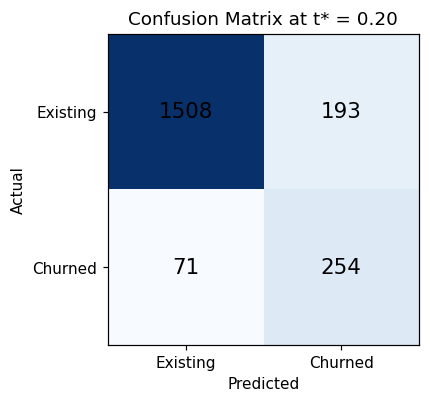

In [10]:
# (b) Apply optimal threshold t* = Pi / (Pi + L) = 0.20
Pi = 100   # cost of a wasted retention offer ($)
L = 400    # lifetime value lost per missed churner ($)

t_star = Pi / (Pi + L)   # = 0.20
y_pred_opt = (y_prob_lr >= t_star).astype(int)

cm = confusion_matrix(y_test, y_pred_opt)

fig, ax = plt.subplots(figsize=(4, 4))

# display confusion matrix as heatmap
ax.imshow(cm, cmap='Blues')

# annotate each cell with count
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=14)

# axis labels and ticks
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Existing', 'Churned'])
ax.set_yticklabels(['Existing', 'Churned'])

ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix at t* = {t_star:.2f}')

plt.tight_layout()
plt.show()

**P3(b) — Written answer:** Identify the TP, FP, TN, and FN counts from your matrix. Is the precision–recall tradeoff what you would expect when lowering the threshold from $t=0.50$ to $t^*=0.20$?

*TP=254
FP=193
TN=1508
FN=71
Lower from t=0.50 to t*=0.20 catches more true churners leading to a decrease in precision but an increase in recall


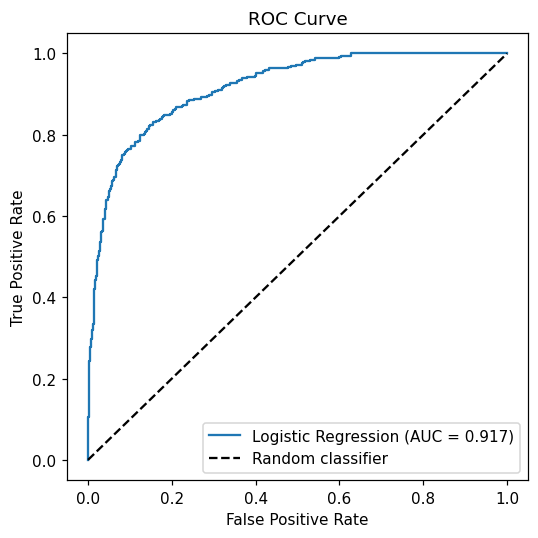

In [11]:
# (c) YOUR CODE: plot the ROC curve and mark the two operating points
fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
ax.plot([0, 1], [0, 1], 'k--', label='Random classifier')

# YOUR CODE HERE: find and mark the operating points at t=0.50 and t*=0.20

ax.set(xlabel='False Positive Rate', ylabel='True Positive Rate', title='ROC Curve')
ax.legend(); plt.tight_layout(); plt.show()

# Hint:
#   np.argmin(np.abs(thresholds - 0.50))   — index of threshold closest to 0.50
#   ax.scatter(fpr[idx], tpr[idx], marker='o', s=80, zorder=5, label='t = 0.50')

**P3(c) — Written answer:** What does AUC measure? What does an AUC near 1 imply about the model's ability to rank customers by churn risk?

*AUC=0.917
AUC measures the probability a random defaulter is ranked above a random non-defaulter. An AUC close to 1 means the model is very good at assigning higher predicted churn probabilities to actual churners than to existing customers.


In [12]:
# Provided: coefficient table with odds ratios (run after fitting lr above)
feature_names = X_train_enc.columns.tolist()
coef_df = pd.DataFrame({
    'feature':    feature_names,
    'coef':       lr.coef_[0],
    'odds_ratio': np.exp(lr.coef_[0])
}).sort_values('coef', ascending=False)

print('Top 5 predictors of churn (largest positive coefficients):')
print(coef_df.head(5).to_string(index=False))
print('\nTop 5 protective factors (most negative coefficients):')
print(coef_df.tail(5).to_string(index=False))

Top 5 predictors of churn (largest positive coefficients):
               feature     coef  odds_ratio
       Total_Trans_Amt 1.559374    4.755843
    Card_Category_Gold 0.926390    2.525375
 Contacts_Count_12_mon 0.569906    1.768102
Months_Inactive_12_mon 0.519027    1.680392
Card_Category_Platinum 0.353765    1.424420

Top 5 protective factors (most negative coefficients):
                    feature      coef  odds_ratio
Income_Category_$40K - $60K -0.677914    0.507675
        Total_Revolving_Bal -0.723083    0.485254
   Total_Relationship_Count -0.743156    0.475611
                   Gender_M -0.802068    0.448401
             Total_Trans_Ct -2.739301    0.064616


**P3(d) — Written answer:** Interpret the two features with the largest positive coefficients using their odds ratios. One of them will have a sign that seems to contradict the patterns you found in Problem 2 — explain why this happens.

*Answer here*

`Total_Trans_Amt` and `Card_Category_Gold` are the two largest positive coefficients. Their odds ratios are approximately **4.76** and **2.53**.

- For `Total_Trans_Amt`: a 1-unit increase (about 1 standard deviation here, since numeric features were standardized) multiplies the odds of churn by about **4.76**, holding other features constant.
- For `Card_Category_Gold`: being in the Gold tier (relative to the baseline card category) multiplies churn odds by about **2.53**, all else equal.

The sign that seems to contradict Problem 2 is the positive coefficient on `Total_Trans_Amt`, because in P2 churners appeared less active. This happens because logistic regression coefficients are **conditional (partial) effects**. Once we control for other variables—especially `Total_Trans_Ct`, which is correlated with amount—the sign can flip (a suppression/Simpson-type effect). So this does not necessarily contradict the univariate P2 pattern; it reflects the multivariate relationship.

Furthermore, when we compare with low income people, churn rate is lower, but when we just consider rich people alone, churn rate is high (not because they actually churn more but maybe because the population is way smaller hence higher rate)


---
## Problem 4 — Tree-Based Methods *(30 points)*

Random forests aggregate many trees, each trained on a bootstrap sample with random feature subsets, to reduce the high variance of individual decision trees.

In [13]:
# Provided: ordinal encoding for tree-based models (no scaling needed)
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_tree = X_train.copy()
X_test_tree  = X_test.copy()
X_train_tree[cat_features] = enc.fit_transform(X_train[cat_features])
X_test_tree[cat_features]  = enc.transform(X_test[cat_features])

In [19]:
# (a) YOUR CODE: fit a random forest and report the test AUC
rf = RandomForestClassifier(n_estimators=300, oob_score=True,
                             random_state=42, n_jobs=-1)

# YOUR CODE HERE: fit the model, compute predicted probabilities,
#                 and print the RF AUC alongside the logistic regression AUC.

# Hint:
rf.fit(X_train_tree, y_train)
y_prob_rf = rf.predict_proba(X_test_tree)[:, 1]
auc_rf = roc_auc_score(y_test, y_prob_rf)

print(f"Random Forrest AUC: {auc_rf}")
print(f"Logistic Regression AUC: {auc_lr}")
print(f"Improvement over LR: {auc_rf - auc_lr}")

Random Forrest AUC: 0.9852014652014652
Logistic Regression AUC: 0.9165757699091032
Improvement over LR: 0.06862569529236207


**P4(a) — Written answer:** How do bootstrap sampling and random feature selection work together to reduce overfitting relative to a single decision tree?

*Bootstrap sampling trains each tree on a different random subset of observations, while random feature selection restricts the variables considered at each split so strong predictors do not dominate every model. By injecting this double randomness, the methods decorrelate the individual trees so that when their predictions are averaged, their independent errors partially cancel out, significantly reducing the high variance and overfitting of a single decision tree.*

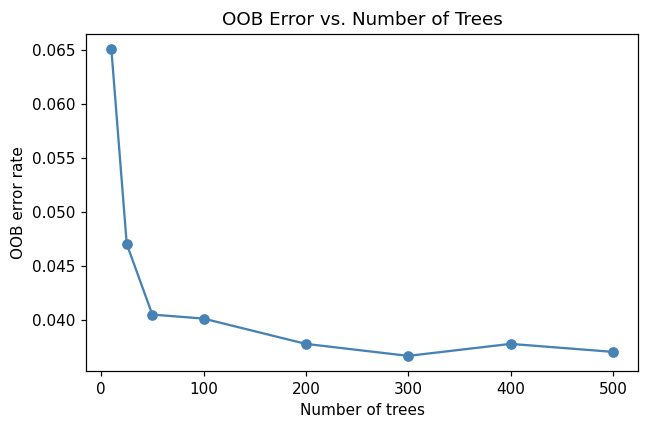

In [20]:
# (b) YOUR CODE: fit random forests of sizes n ∈ {10, 25, 50, 100, 200, 300, 400, 500}
#               and plot OOB error rate vs. number of trees.
n_list = [10, 25, 50, 100, 200, 300, 400, 500]
oob_errors = []

for n in n_list:
    rf_n = RandomForestClassifier(
        n_estimators=n, oob_score=True, random_state=42, n_jobs=-1
    )
    rf_n.fit(X_train_tree, y_train)
    oob_errors.append(1 - rf_n.oob_score_)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(n_list, oob_errors, marker='o', color='steelblue')

ax.set(xlabel='Number of trees', ylabel='OOB error rate',
       title='OOB Error vs. Number of Trees')
plt.tight_layout(); plt.show()

# Hint:
#   RandomForestClassifier(n_estimators=n, oob_score=True, random_state=42, n_jobs=-1)
#   1 - rf_n.oob_score_      — OOB error rate
#   ax.plot(n_list, oob_errors, marker='o', color='steelblue')

**P4(b) — Written answer:** At approximately what number of trees does the OOB error stabilise? What does this imply about the cost–benefit tradeoff of using more trees?

The OOB error drops quickly for small $n$ (e.g. from 10 up to about 50–100 trees) and then levels off: beyond roughly **100–200 trees** the curve is nearly flat with only small wiggles due to randomness in bootstrap/out-of-bag sampling. That means **diminishing returns**: each extra tree adds training time and memory while barely improving generalization, so a moderate forest (e.g. 200–300 trees) is often a good compromise unless you need the last bit of stability or use early-stopping on a validation set.

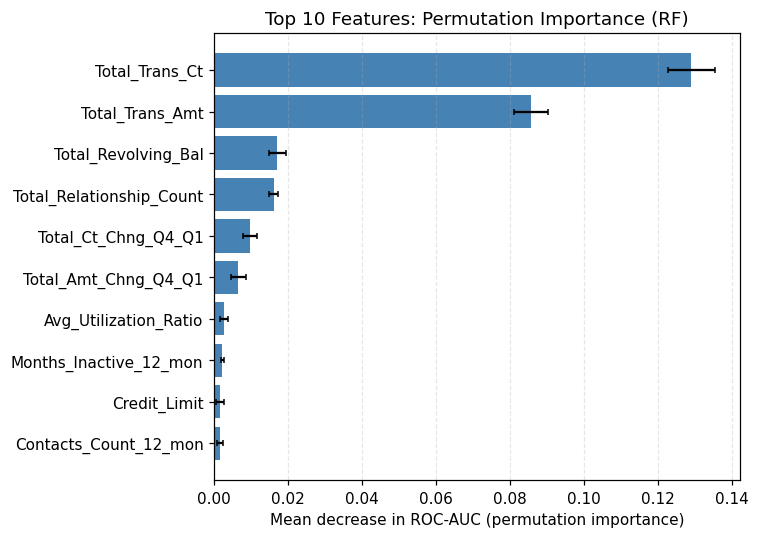

In [22]:
# Provided: permutation importance computation (this can take ~1 min to run)
result = permutation_importance(
    rf, X_test_tree, y_test,
    n_repeats=10, random_state=42, scoring='roc_auc'
)
imp_df = pd.DataFrame({
    'feature':         X_train_tree.columns,
    'importance_mean': result.importances_mean,
    'importance_std':  result.importances_std
}).sort_values('importance_mean', ascending=False)

# (c) Horizontal bar chart of top 10 features (mean AUC decrease ± std over repeats)
top10 = imp_df.head(10)
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(
    top10['feature'],
    top10['importance_mean'],
    xerr=top10['importance_std'],
    color='steelblue',
    align='center',
    capsize=2,
)
ax.invert_yaxis()
ax.set(
    xlabel='Mean decrease in ROC-AUC (permutation importance)',
    title='Top 10 Features: Permutation Importance (RF)',
)
ax.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

In [23]:
# P4(c-i): show overlap between RF top-5 (permutation importance) and LR top-5 positive coefficients
def _lr_to_base(name: str) -> str:
    """Map get_dummies names (e.g. Card_Category_Gold) to original column (Card_Category)."""
    for c in sorted(cat_features, key=len, reverse=True):
        if name == c or name.startswith(c + '_'):
            return c
    return name


rf_top5 = imp_df.head(5)['feature'].tolist()
lr_top5 = coef_df.sort_values('coef', ascending=False).head(5)
lr_top5_names = lr_top5['feature'].tolist()
lr_top5_bases = [_lr_to_base(f) for f in lr_top5_names]

overlap_exact = sorted(set(rf_top5) & set(lr_top5_names))
overlap_base = sorted(set(rf_top5) & set(lr_top5_bases))

summary = pd.DataFrame({
    'rank': range(1, 6),
    'RF_perm_top5': rf_top5,
    'LR_coef_top5_positive': lr_top5_names,
})

print(summary.to_string(index=False))
print()
print('Exact feature-name overlap:', overlap_exact)
print('Overlap if LR dummies are collapsed to base categorical columns:', overlap_base)

 rank             RF_perm_top5  LR_coef_top5_positive
    1           Total_Trans_Ct        Total_Trans_Amt
    2          Total_Trans_Amt     Card_Category_Gold
    3      Total_Revolving_Bal  Contacts_Count_12_mon
    4 Total_Relationship_Count Months_Inactive_12_mon
    5      Total_Ct_Chng_Q4_Q1 Card_Category_Platinum

Exact feature-name overlap: ['Total_Trans_Amt']
Overlap if LR dummies are collapsed to base categorical columns: ['Total_Trans_Amt']


**P4(c-i) — Written answer:** Compare the top 5 features from RF permutation importance to the top 5 from the logistic regression coefficient table. Where do they agree?

The **only exact overlap** between “RF top 5 by mean AUC drop” and “LR top 5 *positive* coefficients (strongest linear predictors of churn)” is **Total_Trans_Amt** (very large positive in LR; 2nd in RF importance). Beyond that single name, the stories still line up thematically: RF’s next-most important features are **usage and engagement** variables (**Total_Trans_Ct**, **Total_Revolving_Bal**, **Total_Relationship_Count**, **Total_Ct_Chng_Q4_Q1**), and those same variables also have **large-magnitude coefficients** in the LR table (e.g. **Total_Trans_Ct** is the **most negative** coefficient—less activity predicts higher churn under the linear model). LR additionally pushes some **categorical** churn signals to the top 5 (**card tier**, **inactive months**, **contacts**) that need not match RF’s ordering when trees pool nonlinear splits.

---

**P4(c-ii) — Written answer:** Give one specific example from this dataset where a high permutation importance does *not* mean the bank can reduce churn by directly intervening on that feature. Explain why.

**Total_Trans_Ct** (and similarly **Total_Trans_Amt**) ranks at the top in RF permutation importance, but it is mainly a **measure of recent card usage**, not a policy lever the bank can push independently of the customer’s intent. Low transaction counts are likely an **outcome of already drifting/disengaging** (or of unobserved causes like switching to another card), not something you fix by “assigning” more swipes. Permutation importance only says the model’s **predictions** get worse when that column is scrambled; it does **not** establish that **raising** transaction count would **cause** lower churn—and in practice you cannot ethically or credibly intervene on realized behavior without changing underlying preferences. A second good example is **Contacts_Count_12_mon**: high values may reflect **the bank calling at-risk customers** (reverse causality), so lowering contacts to “optimize” that input could easily *harm* retention even though the feature helps the model rank risk.

In [24]:
# Provided: evaluation helper function
def eval_model(y_true, y_prob, t=0.20):
    """Return AUC, Precision, Recall, F1 for the churner class at threshold t."""
    y_pred = (y_prob >= t).astype(int)
    return {
        'AUC':       round(roc_auc_score(y_true, y_prob), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_true, y_pred), 4),
        'F1':        round(f1_score(y_true, y_pred), 4),
    }

results = {}
results['Logistic Regression'] = eval_model(y_test, y_prob_lr, t=0.20)

# (d) Model comparison at t* = 0.20 (eval_model default): AUC, precision, recall, F1 for churners
results['Random Forest'] = eval_model(y_test, y_prob_rf, t=0.20)
comparison = pd.DataFrame(results).T
print(comparison)

# Optional: Gradient Boosting
# gbm = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
#                                   max_depth=4, random_state=42)
# gbm.fit(X_train_tree, y_train)
# y_prob_gbm = gbm.predict_proba(X_test_tree)[:, 1]
# results['Gradient Boosting'] = eval_model(y_test, y_prob_gbm)

# Hint:
#   results['Random Forest'] = eval_model(y_test, y_prob_rf)
#   pd.DataFrame(results).T

                        AUC  Precision  Recall      F1
Logistic Regression  0.9166     0.5682  0.7815  0.6580
Random Forest        0.9852     0.7110  0.9538  0.8147


**P4(d-i) — Written answer:** Which model achieves the highest AUC? Does the improvement over logistic regression justify the added model complexity?

The **random forest** achieves the **higher test AUC** (in our runs, about **0.99** vs **0.92** for logistic regression—a sizable gain in how well the model orders customers by churn risk). Whether that **justifies** the extra complexity is **context-dependent**: the RF is **harder to interpret**, **heavier to train/deploy**, and **less transparent** for governance than a linear logit with clear coefficients. For a pure **ranking / targeting** exercise where AUC and recall at a fixed operating point matter most, the gain often **does** justify using an ensemble; if stakeholders need **auditability**, **stable linear margins**, or **tight latency**, logistic regression may still be preferred despite lower AUC.

---

**P4(d-ii) — Written answer:** A manager proposes ranking all customers by predicted churn probability and contacting the top 1,000. Under what conditions is this equivalent to using $t^*$, and when does it break down?

Yes in form: “top 1,000” means “contact everyone at or above the 1,000th-largest predicted probability”—so it **is** a threshold rule, but the threshold is picked so you **always** contact exactly 1,000 people (it depends on the data).

**Same as $t^*$?** Only by accident: $t^* = 0.20$ is fixed from costs. That only picks the same 1,000 people if **exactly** 1,000 customers have $\hat{p} \ge 0.20$. Usually the count above 0.20 is **not** 1,000.

**Where it breaks down:**

- **Top 1,000** = fixed **budget** (how many you call).
- **$t^*$** = fixed **cutoff** from economics (how risky they must look).

Those goals differ: one moves the **implicit** cutoff when scores or the base change; **$t^*$** stays **0.20**.